## **SNAP Jupyter demo notebook**
**Geocoded Single Look Complex (GSLC) and GSLC-based InSAR for Sentinel-1...**

In summary, this workflow contains:

- Explain what a GSLC product is and how `GSLC-Terrain-Correction` differs from the classical detected `Terrain-Correction`
- Build a single GSLC product from a Sentinel-1 Stripmap SLC and inspect it
- Run a Stripmap GSLC InSAR pair (interferogram + coherence) using `CreateStack` + `Interferogram`
- Repeat the InSAR pair for Sentinel-1 IW (TOPS) using `TOPSAR-Split` ahead of `GSLC-Terrain-Correction`
- Compare the classical and GSLC InSAR processing chains side-by-side

Complexity: advanced

##### ***About the test data:***

This notebook ships a small **Envisat ASAR Image-Mode (Stripmap) SLC pair** over **Santorini** in
`data/Santorini/` (same track, ~35-day baseline, Feb/Mar 2004), so **Part 1 (Stripmap GSLC and
GSLC-InSAR) runs out of the box** - no download needed. `GSLC-Terrain-Correction` is
mission-agnostic; the only mission-specific setting is the precise-orbit source (`sm_orbit_type`:
DORIS for Envisat, `'Sentinel Precise (Auto Download)'` for Sentinel-1).

**Part 2 (Sentinel-1 IW / TOPS)** needs your own S1 IW SLC pair (same track, short baseline) from
the [Copernicus Browser](https://dataspace.copernicus.eu/browser/). Drop both `.SAFE` directories
into `data/`, set `iw_reference_slc` / `iw_secondary_slc`, and Part 2 runs; otherwise it is skipped.

Precise orbits and the Copernicus 30 m DEM are auto-downloaded on first run (internet required).

##### ***Some information on the Python environment:***

In [1]:
import os
import sys
print("Python version: " + sys.version)

import sysconfig
print("Location of esa_snappy package: " + sysconfig.get_paths()['purelib'] + os.sep + "esa_snappy")

Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
Location of esa_snappy package: C:\Users\luis_\AppData\Local\Programs\Python\Python313\Lib\site-packages\esa_snappy


##### ***Import Python packages...***

**Note:** The imports of *esa_snappy* and *snapista* may emit Info/Warning messages from SNAP core. They can be ignored here.

In [2]:
import esa_snappy
from esa_snappy import ProductIO

import snapista
from snapista import Graph
from snapista import Operator

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

##### ***Convenience plot functions:***

We reuse these throughout the notebook to display real, imaginary, intensity, phase and coherence bands.

In [3]:
def _read_dec(band, target=1400):
    """Read a band downsampled to ~target px on the long side, in row strips (avoids the
    'Cannot construct DataBuffer' that a full-resolution read of a large/virtual band triggers)."""
    w, h = band.getRasterWidth(), band.getRasterHeight()
    dec = max(1, int(max(w, h) / target))
    cols = list(range(0, w, dec))
    block = dec * 64
    rows = []
    for y in range(0, h, block):
        bh = min(block, h - y)
        buf = np.zeros(w * bh, np.float32)
        band.readPixels(0, y, w, bh, buf)
        buf.shape = (bh, w)
        rows.append(buf[::dec][:, cols])
    return np.vstack(rows)

def plot_complex(product, i_band_name, q_band_name, title_prefix=""):
    """Plot intensity (log) and wrapped phase of an I/Q band pair (decimated for display)."""
    i = _read_dec(product.getBand(i_band_name))
    q = _read_dec(product.getBand(q_band_name))
    intensity = i * i + q * q
    phase = np.ma.masked_where((i == 0) & (q == 0), np.arctan2(q, i))
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].set_title(f"{title_prefix} intensity (log)")
    axs[0].imshow(np.log1p(intensity), cmap='gray')
    axs[1].set_title(f"{title_prefix} wrapped phase")
    axs[1].imshow(phase, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    plt.show()

def plot_interferogram(product, *_ignored):
    """Plot the wrapped interferogram phase (from the real i_ifg/q_ifg bands) and coherence."""
    names = [b.getName() for b in product.getBands()]
    iN = next(n for n in names if n.lower().startswith('i_ifg')
              or (n.lower().startswith('i_') and product.getBand(n).getUnit() == 'real'))
    qN = ('q_' + iN[2:]) if iN.lower().startswith('i_ifg') else iN.replace('i_', 'q_', 1)
    cohN = next((n for n in names if n.lower().startswith('coh')), None)
    i = _read_dec(product.getBand(iN)); q = _read_dec(product.getBand(qN))
    mask = (i == 0) & (q == 0)
    phi = np.ma.masked_where(mask, np.arctan2(q, i))
    if cohN is None:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(phi, cmap='hsv', vmin=-np.pi, vmax=np.pi)
        ax.set_title('Wrapped interferogram phase [rad]'); fig.colorbar(im, ax=ax)
    else:
        coh = np.ma.masked_where(mask, _read_dec(product.getBand(cohN)))
        print('mean coherence = %.2f' % float(np.ma.mean(coh)))
        fig, axs = plt.subplots(1, 2, figsize=(13, 6))
        im0 = axs[0].imshow(phi, cmap='hsv', vmin=-np.pi, vmax=np.pi)
        axs[0].set_title('Wrapped interferogram phase [rad]'); fig.colorbar(im0, ax=axs[0], fraction=0.046)
        im1 = axs[1].imshow(coh, cmap='viridis', vmin=0, vmax=1)
        axs[1].set_title('Coherence [0-1]'); fig.colorbar(im1, ax=axs[1], fraction=0.046)
    plt.show()

---

### ***What is a GSLC product?***

A **Geocoded Single Look Complex (GSLC)** product is a SAR product where:

1. The pixels are **already in a map projection** (e.g. WGS84 lat/lon) — same as a classical terrain-corrected product.
2. The pixels are **still complex** (I + jQ) — same as a slant-range SLC.

In short, *"a terrain-corrected SLC"*. Compared to a slant-range SLC, the major advantages are:

- Coregistration of two GSLC products reduces to a simple map-coordinate stack — no `Back-Geocoding`, no `Enhanced-Spectral-Diversity` iteration.
- The interferogram phase no longer contains the flat-earth or topographic phase contributions: those have already been removed by `GSLC-Terrain-Correction`. Downstream operators key on the abstract-metadata flag `is_terrain_corrected = 1` and skip flat-earth / topo-phase subtraction automatically.
- The output is directly usable by GIS-style tools that expect map-projected raster input.

GSLC processing was introduced for missions like NISAR. SNAP supports it across Sentinel-1 (Stripmap and IW), Capella, ICEYE and other SAR sources via the `GSLC-Terrain-Correction` operator.

---

### ***What `GSLC-Terrain-Correction` does***

Naïvely resampling complex I/Q data onto a map grid destroys the phase: a sub-pixel offset between source and target rotates the phasor by an arbitrary amount. `GSLC-Terrain-Correction` solves this in three steps:

1. **Phase flattening** — subtract the carrier (range/azimuth) phase contribution from the input complex pixels, so the remaining signal is locally smooth and safe to interpolate.
2. **High-fidelity complex resampling** — interpolate I and Q separately with a windowed-sinc kernel (`BISINC_5_POINT` by default).
3. **Optional phase restoration** — re-apply the flattened carrier on the geocoded grid so the output is a "true" map-projected SLC. With `outputFlattened=False` (**the default**) the carrier is restored on the geocoded grid — this is the form required for InSAR. `outputFlattened=True` leaves the carrier removed, which zeroes the interferometric phase and is **not** usable for InSAR.

Important user-facing parameters:

| Parameter | Default | Notes |
|:----------|:--------|:------|
| `demName` | `Copernicus 30m Global DEM` | Auto-downloaded by SNAP on first use |
| `demResamplingMethod` | `BILINEAR_INTERPOLATION` | For sampling the DEM |
| `imgResamplingMethod` | `BISINC_5_POINT_INTERPOLATION` | Complex image resampler — use sinc-family for phase preservation |
| `outputFlattened` | `false` | Keep the geometric carrier (**required for InSAR**); `true` removes it and zeroes the (R_master - R_slave) interferometric phase |
| `nodataValueAtSea` | `true` | Mask water bodies (much faster) |
| `saveIncidenceAngleFromEllipsoid` / `saveLocalIncidenceAngle` / `saveLayoverShadowMask` | `false` | Optional auxiliary bands |

For Sentinel-1 IW TOPS data, **always** run `TOPSAR-Split` first to pick a single subswath and a contiguous burst range. Debursted TOPS SLCs are explicitly rejected by `GSLC-Terrain-Correction`.

---

### ***Configure input paths***

Edit the paths below to point to your downloaded SLCs.

In [4]:
data_dir = os.path.join(os.getcwd(), 'data')
graphs_dir = os.path.join(os.getcwd(), 'graphs')
results_dir = os.path.join(os.getcwd(), 'results')
os.makedirs(graphs_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# --- cached data fetch (public S3 / HTTP; re-runs reuse the local copy) ---
import urllib.request as _urlreq, zipfile as _zip, glob as _glob

def fetch_cached(url, dest_dir):
    """Download `url` into dest_dir unless already present, unzip a .zip, and return the path to
    open (manifest.safe for a .SAFE product, else the downloaded file). Cached for re-runs:
    if the product is already in dest_dir it is NOT downloaded again."""
    os.makedirs(dest_dir, exist_ok=True)
    fname = url.split('/')[-1]
    stem = fname[:-4] if fname.lower().endswith('.zip') else fname
    hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe'))
    if hits:
        print('cached:', os.path.basename(os.path.dirname(hits[0]))); return hits[0]
    local = os.path.join(dest_dir, fname)
    if not os.path.exists(local):
        print('downloading', fname, '...')
        _urlreq.urlretrieve(url, local)
        print('  saved %.0f MB' % (os.path.getsize(local) / 1e6))
    if fname.lower().endswith('.zip'):
        with _zip.ZipFile(local) as z:
            z.extractall(dest_dir)
        hits = _glob.glob(os.path.join(dest_dir, stem + '*', 'manifest.safe'))
        return hits[0] if hits else local
    return local

# Make the gpt subprocess emit UTF-8 console text. snapista decodes gpt's stdout as UTF-8;
# on Windows gpt would otherwise emit cp1252 bytes and snapista raises UnicodeDecodeError.
os.environ.setdefault('JAVA_TOOL_OPTIONS',
                      '-Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8')

# --- Stripmap pair (auto-downloaded) ---
# Envisat ASAR Image-Mode (Stripmap) SLC subset pair over Santorini, same track, ~35 days apart
# (25 Feb 2004 / 31 Mar 2004). Downloaded once from public S3 as a BEAM-DIMAP zip and cached in
# data/Santorini/. Stripmap SLCs from any mission work; for a Sentinel-1 SM pair point these at the
# .SAFE manifest.safe files and set sm_orbit_type to 'Sentinel Precise (Auto Download)'.
santorini = os.path.join(data_dir, 'Santorini')
SANTORINI_ZIP = 'https://skywatch-public.s3.us-west-2.amazonaws.com/snap/data/ASAR/Santorini/Santorini.zip'
sm_reference_name = 'subset_3_of_ASA_IMS_1PNUPA20040225_200558_000000162024_00329_10403_7640.dim'
sm_secondary_name = 'subset_4_of_ASA_IMS_1PNUPA20040331_200601_000000162025_00329_10904_7641.dim'

def fetch_dimap_zip(url, dest_dir, dim_names):
    """Fetch a BEAM-DIMAP product zip (one or more <name>.dim + <name>.data trees) into dest_dir,
    extracting once; return the local .dim path for each name in dim_names. Cached: if every .dim is
    already present locally it is NOT downloaded again (re-runs reuse the extracted copy)."""
    os.makedirs(dest_dir, exist_ok=True)
    def _find(n):
        h = _glob.glob(os.path.join(dest_dir, '**', n), recursive=True)
        return h[0] if h else None
    if all(_find(n) for n in dim_names):
        print('cached: Santorini pair'); return [_find(n) for n in dim_names]
    local = os.path.join(dest_dir, url.split('/')[-1])
    if not os.path.exists(local):
        print('downloading', url.split('/')[-1], '...'); _urlreq.urlretrieve(url, local)
        print('  saved %.0f MB' % (os.path.getsize(local) / 1e6))
    with _zip.ZipFile(local) as z:
        z.extractall(dest_dir)
    out = []
    for n in dim_names:
        p = _find(n)
        if not p:
            raise RuntimeError(f'{n} not found after extracting {url}')
        out.append(p)
    return out

sm_reference_slc, sm_secondary_slc = fetch_dimap_zip(SANTORINI_ZIP, santorini,
                                                     [sm_reference_name, sm_secondary_name])
sm_orbit_type = 'DORIS Precise VOR (ENVISAT) (Auto Download)'  # Envisat; S1 -> 'Sentinel Precise (Auto Download)'

# --- TOPS (IW) pair (Sentinel-1) ---
# A 12-day Mount Etna IW SLC pair hosted publicly on S3: downloaded on first run (~4 GB each) and
# cached in data/. Set RUN_IW = True to also run the Sentinel-1 IW pair (GSLC-InSAR for TOPS is not yet coherent - see 2B).
RUN_IW = False
_etna = 'https://skywatch-public.s3.us-west-2.amazonaws.com/snap/data/S1/SLC/Etna-DLR/'
if RUN_IW:
    iw_reference_slc = fetch_cached(_etna + 'S1A_IW_SLC__1SDV_20140809T165546_20140809T165613_001866_001C20_088B.zip', data_dir)
    iw_secondary_slc = fetch_cached(_etna + 'S1A_IW_SLC__1SDV_20140821T165547_20140821T165614_002041_001FC1_8601.zip', data_dir)
else:
    iw_reference_slc = iw_secondary_slc = None
iw_orbit_type = 'Sentinel Precise (Auto Download)'
run_iw = bool(RUN_IW and iw_reference_slc and os.path.exists(iw_reference_slc))


def gslc_insar_pair(ref_slc, sec_slc, orbit_type, tops, tag):
    """GSLC interferometric pair the way the coregistration fix expects it:
    geocode ONLY the master (from a written, orbit-applied SLC so GSLC stamps its source path),
    then hand CreateStack the master GSLC + the RAW slave SLC. CreateStack reloads the master SLC
    from the stamp, cross-correlates it against the slave to estimate the (range, azimuth) bias,
    and re-geocodes the slave with that bias before stacking. (Stacking two pre-made GSLCs instead
    skips the bias step and yields an incoherent interferogram.)"""
    # (1) Master prep -> disk, so the GSLC's source has a file location to stamp.
    gm = Graph()
    gm.add_node(operator=Operator('Read', file=ref_slc), node_id='Read')
    gm.add_node(operator=Operator('Apply-Orbit-File', orbitType=orbit_type, continueOnFail='true'),
                node_id='Orbit', source='Read')
    last = 'Orbit'
    if tops:
        gm.add_node(operator=Operator('TOPSAR-Split', subswath='IW1', selectedPolarisations='VV',
                                      firstBurstIndex='1', lastBurstIndex='3'),
                    node_id='Split', source='Orbit')
        last = 'Split'
    master_prep = os.path.join(results_dir, f'gslc_{tag}_master_prep.dim')
    gm.add_node(operator=Operator('Write', file=master_prep, formatName='BEAM-DIMAP'),
                node_id='Write', source=last)
    gm.run()

    # (2) GSLC(master) + raw slave SLC -> CreateStack (auto bias) -> Interferogram.
    g = Graph()
    g.add_node(operator=Operator('Read', file=master_prep), node_id='ReadM')
    g.add_node(operator=Operator('GSLC-Terrain-Correction',
                                 demName='Copernicus 30m Global DEM',
                                 imgResamplingMethod='BISINC_5_POINT_INTERPOLATION',
                                 outputFlattened='false'),
               node_id='GSLC_M', source='ReadM')
    g.add_node(operator=Operator('Read', file=sec_slc), node_id='ReadS')
    g.add_node(operator=Operator('Apply-Orbit-File', orbitType=orbit_type, continueOnFail='true'),
               node_id='OrbitS', source='ReadS')
    slast = 'OrbitS'
    if tops:
        g.add_node(operator=Operator('TOPSAR-Split', subswath='IW1', selectedPolarisations='VV',
                                     firstBurstIndex='1', lastBurstIndex='3'),
                   node_id='SplitS', source='OrbitS')
        slast = 'SplitS'
    # Master GSLC first (reference), raw slave SLC second -> CreateStack auto-coregisters the slave.
    g.add_node(operator=Operator('CreateStack', extent='Master'),
               node_id='Stack', source=['GSLC_M', slast])
    g.add_node(operator=Operator('Interferogram', includeCoherence='true', cohWinAz='10', cohWinRg='10'),
               node_id='Ifg', source='Stack')
    g.add_node(operator=Operator('GoldsteinPhaseFiltering', alpha='1.0'),
               node_id='Gold', source='Ifg')
    out = os.path.join(results_dir, f'snap_nb_gslc_{tag}_insar.dim')
    g.add_node(operator=Operator('Write', file=out, formatName='BEAM-DIMAP'),
               node_id='Write', source='Gold')
    g.save_graph(os.path.join(graphs_dir, f'snap_nb_gslc_{tag}_insar.xml'))
    g.run()
    return out

---
## ***Part 1 — Stripmap GSLC***
---

### ***1A. Build a single Stripmap GSLC product***

For a Stripmap SLC the chain is short: `Read → Apply-Orbit-File → GSLC-Terrain-Correction → Write`. `Apply-Orbit-File` pulls Precise Orbit Ephemerides (POE) from ESA, which gives the geocoding the position accuracy InSAR needs.

In [5]:
g_sm_single = Graph()
g_sm_single.add_node(operator=Operator('Read', file=sm_reference_slc), node_id='Read')

g_sm_single.add_node(operator=Operator('Apply-Orbit-File',
                                       orbitType=sm_orbit_type,
                                       continueOnFail='true'),
                     node_id='ApplyOrbit', source='Read')

g_sm_single.add_node(operator=Operator('GSLC-Terrain-Correction',
                                       demName='Copernicus 30m Global DEM',
                                       imgResamplingMethod='BISINC_5_POINT_INTERPOLATION',
                                       alignToStandardGrid='true',
                                       outputFlattened='false'),
                     node_id='GSLC', source='ApplyOrbit')

sm_single_out = os.path.join(results_dir, 'snap_nb_gslc_sm_single.dim')
g_sm_single.add_node(operator=Operator('Write', file=sm_single_out, formatName='BEAM-DIMAP'),
                     node_id='Write', source='GSLC')

g_sm_single.view()
g_sm_single.save_graph(os.path.join(graphs_dir, 'snap_nb_gslc_sm_single.xml'))

<graph>
  <version>1.0</version>
  <node id="Read">
    <operator>Read</operator>
    <sources/>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <bandNames/>
      <copyMetadata>true</copyMetadata>
      <file>E:\ESA\snap-jupyter-notebooks\resources\jupyter_notebooks\data\Santorini\subset_3_of_ASA_IMS_1PNUPA20040225_200558_000000162024_00329_10403_7640.dim</file>
      <formatName/>
      <geometryRegion/>
      <maskNames/>
      <pixelRegion/>
      <polygonRegion/>
      <useAdvancedOptions>false</useAdvancedOptions>
      <vectorFile/>
    </parameters>
  </node>
  <node id="ApplyOrbit">
    <operator>Apply-Orbit-File</operator>
    <sources>
      <sourceProduct refid="Read"/>
    </sources>
    <parameters class="com.bc.ceres.binding.dom.XppDomElement">
      <continueOnFail>true</continueOnFail>
      <orbitType>DORIS Precise VOR (ENVISAT) (Auto Download)</orbitType>
      <polyDegree>3</polyDegree>
    </parameters>
  </node>
  <node id="GSLC">
    <operat

##### ***Run the graph and inspect the result:***

In [6]:
g_sm_single.run()

Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
....11%....22%....33%....45%....56%....67%....78%....90% done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
INFO: eu.esa.sar.sar.gpf.geometric.GSLCGeocodingOp: GSLC: residual Doppler centroid built from 5 coefficient(s); |f_dc| range across swath = 611.22 Hz (max). Azimuth deramp will be applied during SM resampling.
-- org.jblas INFO Starting temp DLL cleanup task.
-- org.jblas INFO Deleted 4 unused temp DLL libraries from C:\Users\luis_\AppData\Local\Temp
Processing finished successfully.


0

Bands: ['i_VV', 'q_VV', 'Intensity_VV']
Width x Height: 3632 x 2270
GeoCoding: GeoCoding


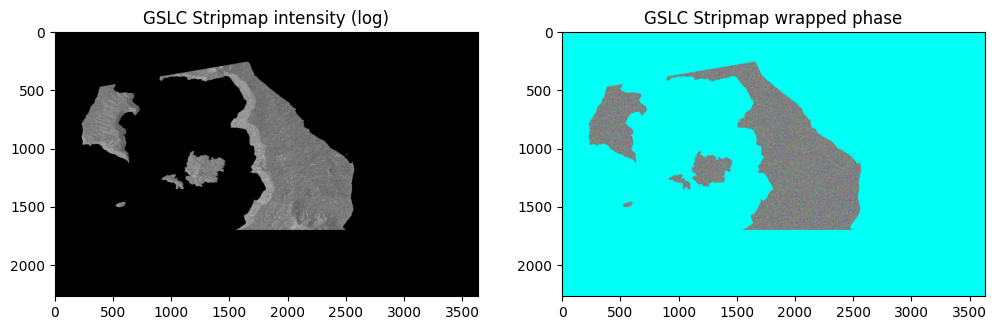

In [7]:
p_sm_gslc = ProductIO.readProduct(sm_single_out)
print('Bands:', [b.getName() for b in p_sm_gslc.getBands()])
print('Width x Height:', p_sm_gslc.getSceneRasterWidth(), 'x', p_sm_gslc.getSceneRasterHeight())
print('GeoCoding:', p_sm_gslc.getSceneGeoCoding().__class__.__name__)

# Detect the polarisation suffix actually present
i_name = next(b.getName() for b in p_sm_gslc.getBands()
              if b.getName().startswith('i_') and b.getUnit() == 'real')
q_name = i_name.replace('i_', 'q_', 1)
plot_complex(p_sm_gslc, i_name, q_name, title_prefix='GSLC Stripmap')
p_sm_gslc.dispose()

---

### ***1B. Stripmap GSLC InSAR pair***

> **Coherence caveat.** A coherent GSLC interferogram needs the two GSLCs sub-pixel coregistered.
> That is handled by `CreateStack`'s automatic cross-correlation **bias** estimation — implemented
> here as: geocode only the **master**, then hand `CreateStack` the master GSLC **plus the raw
> slave SLC** (see `gslc_insar_pair`). CreateStack reloads the master SLC, cross-correlates it
> against the slave to estimate the (range, azimuth) bias, and re-geocodes the slave with it.
> This auto-bias is **Stripmap-only** and needs a *small* initial offset for cross-correlation to
> lock. The bundled Santorini subsets are offset by ~100+ px, so the cross-correlation does **not**
> lock and this pair stays incoherent — it demonstrates the *graph*, not a coherent result. A
> small-offset Stripmap pair (full scenes / properly co-subset) is required for fringes. For
> Sentinel-1 IW/TOPS, use the classical Back-Geocoding + ESD chain
> ([snap-nb-sar-s1-classical-insar-displacement](snap-nb-sar-s1-classical-insar-displacement.ipynb)).

In [8]:
# Bias-enabled GSLC InSAR (see gslc_insar_pair): geocode the master, hand CreateStack the master
# GSLC + the raw slave SLC so it estimates the cross-correlation bias and coregisters the slave.
sm_insar_out = gslc_insar_pair(sm_reference_slc, sm_secondary_slc, sm_orbit_type, tops=False, tag='sm')

Processing the graph, this may take a while. Please wait...


standard output of subprocess: 
Executing processing graph
....11%....21%....31%....41%....52%....62%....72%....82%.... done.
standard error of subprocess: 
Picked up JAVA_TOOL_OPTIONS: -Dsun.stdout.encoding=UTF-8 -Dsun.stderr.encoding=UTF-8
INFO: org.esa.snap.core.gpf.operators.tooladapter.ToolAdapterIO: Initializing external tool adapters
INFO: org.esa.snap.core.util.EngineVersionCheckActivator: Please check regularly for new updates for the best SNAP experience.
[main] INFO hdf.hdflib.HDFLibrary - HDF4 library: 
[main] INFO hdf.hdflib.HDFLibrary -  successfully loaded.
[main] INFO hdf.hdf5lib.H5 - HDF5 library: 
[main] INFO hdf.hdf5lib.H5 -  successfully loaded.
INFO: eu.esa.sar.sar.gpf.geometric.GSLCGeocodingOp: GSLC: residual Doppler centroid built from 5 coefficient(s); |f_dc| range across swath = 611.22 Hz (max). Azimuth deramp will be applied during SM resampling.
INFO: eu.esa.sar.sar.gpf.geometric.GSLCGeocodingOp: GSLC: residual Doppler centroid built from 5 coefficient(s); |f

0

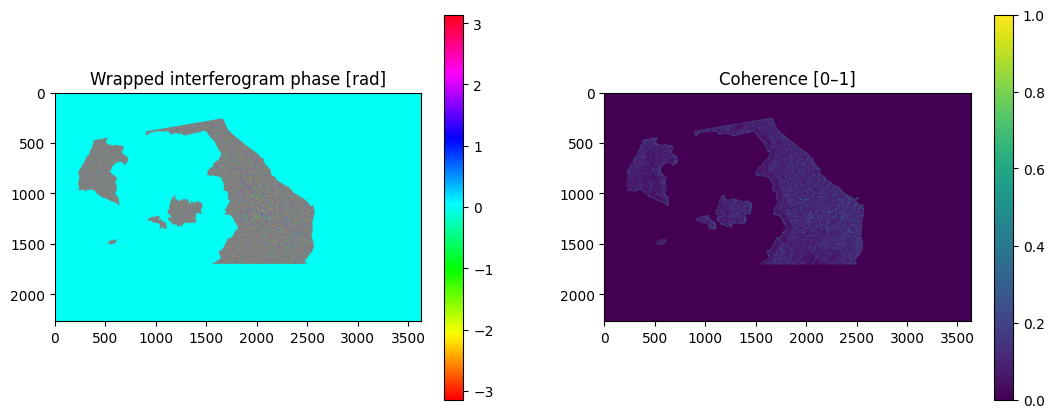

In [9]:
p_sm_ifg = ProductIO.readProduct(sm_insar_out)
print('Bands:', [b.getName() for b in p_sm_ifg.getBands()])
plot_interferogram(p_sm_ifg)
p_sm_ifg.dispose()

---
## ***Part 2 — TOPS (Sentinel-1 IW) GSLC***
---

### ***2A. Build a single IW GSLC product***

The IW chain inserts `TOPSAR-Split` before `GSLC-Terrain-Correction`: pick one subswath (`IW1` here) and the burst range you want to process. `GSLC-Terrain-Correction` rejects already-debursted TOPS products explicitly, so the burst structure must be preserved.

> Processing chain: `Read → Apply-Orbit-File → TOPSAR-Split → GSLC-Terrain-Correction → Write`

In [10]:
if not run_iw:
    print('No Sentinel-1 IW pair in data/ - skipping Part 2 (IW GSLC). '
          'Set iw_reference_slc / iw_secondary_slc to a downloaded S1 IW pair to run it.')
else:
    g_iw_single = Graph()
    g_iw_single.add_node(operator=Operator('Read', file=iw_reference_slc), node_id='Read')
    g_iw_single.add_node(operator=Operator('Apply-Orbit-File',
                                           orbitType=iw_orbit_type, continueOnFail='true'),
                         node_id='ApplyOrbit', source='Read')
    g_iw_single.add_node(operator=Operator('TOPSAR-Split',
                                           subswath='IW1',
                                           selectedPolarisations='VV',
                                           firstBurstIndex='1',
                                           lastBurstIndex='3'),
                         node_id='Split', source='ApplyOrbit')
    g_iw_single.add_node(operator=Operator('GSLC-Terrain-Correction',
                                           demName='Copernicus 30m Global DEM',
                                           imgResamplingMethod='BISINC_5_POINT_INTERPOLATION',
                                           alignToStandardGrid='true',
                                           outputFlattened='false'),
                         node_id='GSLC', source='Split')
    iw_single_out = os.path.join(results_dir, 'snap_nb_gslc_iw_single.dim')
    g_iw_single.add_node(operator=Operator('Write', file=iw_single_out, formatName='BEAM-DIMAP'),
                         node_id='Write', source='GSLC')
    g_iw_single.view()
    g_iw_single.save_graph(os.path.join(graphs_dir, 'snap_nb_gslc_iw_single.xml'))
    g_iw_single.run()

No Sentinel-1 IW pair in data/ - skipping Part 2 (IW GSLC). Set iw_reference_slc / iw_secondary_slc to a downloaded S1 IW pair to run it.


In [11]:
if run_iw:
    p_iw_gslc = ProductIO.readProduct(iw_single_out)
    print('Bands:', [b.getName() for b in p_iw_gslc.getBands()])
    i_name = next(b.getName() for b in p_iw_gslc.getBands()
                  if b.getName().startswith('i_') and b.getUnit() == 'real')
    q_name = i_name.replace('i_', 'q_', 1)
    plot_complex(p_iw_gslc, i_name, q_name, title_prefix='GSLC IW1')
    p_iw_gslc.dispose()

---

### ***2B. IW (TOPS) GSLC InSAR pair***

> **Not coherent in this build.** `CreateStack`'s auto-bias coregistration **explicitly refuses
> S1 TOPS** (`For S1 TOPS SLC products, TOPS Coregistration should be used`), so the slave is left
> uncoregistered and the interferogram is noise. GSLC-InSAR for Sentinel-1 IW is a **work in
> progress**; for a coherent IW interferogram use the classical Back-Geocoding + ESD chain
> ([snap-nb-sar-s1-classical-insar-displacement](snap-nb-sar-s1-classical-insar-displacement.ipynb),
> which reaches ~0.6 coherence on the same Etna pair). The cells below run the GSLC graph for
> illustration only, and only if you set `RUN_IW = True` in the config (it downloads ~8 GB).

In [12]:
if not run_iw:
    print('No Sentinel-1 IW pair in data/ - skipping Part 2 IW InSAR.')
else:
    iw_insar_out = gslc_insar_pair(iw_reference_slc, iw_secondary_slc, iw_orbit_type, tops=True, tag='iw')

Skipping Part 2 IW InSAR pair (no Sentinel-1 IW data).


In [13]:
if run_iw:
    p_iw_ifg = ProductIO.readProduct(iw_insar_out)
    print('Bands:', [b.getName() for b in p_iw_ifg.getBands()])
    plot_interferogram(p_iw_ifg)
    p_iw_ifg.dispose()

---

### ***Comparison: classical InSAR vs. GSLC InSAR (Sentinel-1 IW)***

| Step | Classical IW InSAR | GSLC IW InSAR |
|:-----|:-------------------|:--------------|
| 1 | `Read` (ref + sec) | `Read` (ref + sec) |
| 2 | `Apply-Orbit-File` | `Apply-Orbit-File` |
| 3 | `TOPSAR-Split` | `TOPSAR-Split` |
| 4 | `Back-Geocoding` (uses DEM to predict pixel offsets) | `GSLC-Terrain-Correction` (uses DEM + complex resample) |
| 5 | `Enhanced-Spectral-Diversity` (iterative refinement) | `CreateStack` |
| 6 | `Interferogram` (with flat-earth + topo subtraction) | `Interferogram` (auto-skips both, sees `is_terrain_corrected=1`) |
| 7 | `TOPSAR-Deburst` | *(not needed — bursts merged during geocoding)* |
| 8 | `TopoPhaseRemoval` | *(already removed)* |
| 9 | `GoldsteinPhaseFiltering` | `GoldsteinPhaseFiltering` |
| 10 | `Terrain-Correction` (range-Doppler) | *(already geocoded)* |

The GSLC chain trades one heavier per-product step (the complex terrain correction) for the elimination of `Back-Geocoding`, `Enhanced-Spectral-Diversity`, `TOPSAR-Deburst`, `TopoPhaseRemoval` **and** the final `Terrain-Correction`. The result is also map-projected from the start, so it integrates cleanly with downstream GIS tooling.

---

### ***Summary***

What have we learnt in this notebook?

- A **GSLC** product is a complex SAR product that has already been map-projected with phase preservation.
- `GSLC-Terrain-Correction` accomplishes this via phase flattening, sinc-family complex resampling, and (optional) phase restoration. The default `Copernicus 30m Global DEM` is auto-downloaded by SNAP and the default sinc-5 resampler is appropriate for InSAR.
- For Sentinel-1 Stripmap, the GSLC chain is `Read → Apply-Orbit-File → GSLC-Terrain-Correction`.
- For Sentinel-1 IW (TOPS), insert `TOPSAR-Split` before `GSLC-Terrain-Correction`; debursted TOPS products are rejected by design.
- An InSAR pair from two GSLCs is just `CreateStack → Interferogram`: the operator detects `is_terrain_corrected=1` and skips flat-earth/topo phase subtraction.
- Compared to the classical IW InSAR chain, the GSLC chain removes four operators end-to-end and produces a map-projected interferogram directly.